# Stokes-MHD relations

## 1. Prerrequisites

In [24]:
import sys
import numpy as np
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/")
from pathlib import Path

from scipy.stats import pearsonr
from scipy.optimize import curve_fit


from astropy.constants import c, e, m_e
from astropy import units as u

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from utils.muram_data import MhdData, StokesData

plt.rcParams.update({
  'axes.titlesize': 'x-large',  # heading 1
  'axes.labelsize': 'large',   # heading 2
  'xtick.labelsize': 'medium',         # fontsize of the ticks
  'ytick.labelsize': 'medium',         # fontsize of the ticks
  'font.family': 'serif',        # Font family
  'text.usetex': False,          # Do not use LaTeX for text rendering
  'figure.figsize': (10, 8),     # Default figure size
  'savefig.dpi': 300,            # High resolution for saving figures
  'savefig.format': 'png',       # Default format for saving figures
  'legend.fontsize': 'small',  # Font size for legends
  'lines.linewidth': 2,          # Line width for plots
  'lines.markersize': 8,         # Marker size for plots,
  'axes.formatter.useoffset': False,  # Disable offset
  'axes.formatter.use_mathtext': True,  # Use scientific notation
  'axes.formatter.limits': (-3, 4),  # Use scientific notation for values over 10^2
  'axes.labelsize': 'large',     # Font size for axes labels
  'figure.titlesize': 'xx-large', # Font size for suptitles (heading 1)
  'axes.formatter.use_locale': False  # Do not use locale settings
})



data_path = Path("/scratchsan/observatorio/juagudeloo/data/")
images_dir = Path("./notebooks_images/sample_step/")
step = 180

## 2. Charge data

### 2.1 MHD

Let's charge the sample step for the MHD data.

In [2]:
mhd = MhdData(
    data_path=data_path / "muram-simulation",
    nx=480, ny=480, nz=256
)

# Load a simulation step
mhd.load_step(step=step, z_max=250)

# Load opacity table and compute optical depth
mhd.load_opacity_table(kappa_path= data_path / "csv/kappa.0.dat")
mhd.compute_optical_depth(dz=1e6)

# Remap to optical depth coordinates
new_logtau = np.arange(-2.0, 0.1, 0.1)
mhd.remap_to_optical_depth(new_logtau, quantities=["T", "Vz", "Bz"])
print("MHD uploaded!")

Loading step 180000
  Trimmed z axis to first 250 layers (0..249)
  Reference layer (T ~ 5780 K) at z-index 197
  Done.
Opacity interpolator loaded from /scratchsan/observatorio/juagudeloo/data/csv/kappa.0.dat
  T range: [3.320, 5.300] (log10 K)
  P range: [-2.000, 8.000] (log10 dyne/cm²)
Computing optical depth...


  Optical depth computed.
Remapping to optical depth coordinates (21 levels)...
  Processing T
  Processing Vz
  Processing Bz
  Remapping complete.
MHD uploaded!


### 2.2 Stokes

Let's charge the stokes data for the sample step.

In [3]:
# Initialize
stokes = StokesData(
    data_dir=data_path / "muram-simulation/",
    step=step,
    wavelength_range=(6300.5, 6303.5),
    wavelength_step=0.01
)

# Load Stokes cube
stokes.load_stokes()
stokes.continuum_normalization(cont_indices=[0, 1, 2, 3])
stokes.load_hinode_lsf(data_path / "hinode-MODEST/PSFs/hinode_sp.spline.psf")
stokes.apply_spectral_convolution()
stokes.resample_to_hinode()
#stokes.add_hinode_noise(noise_level=5.9e-4)
print("Stokes uploaded!")

Loading Stokes data from /scratchsan/observatorio/juagudeloo/data/muram-simulation/stokes_180000.npy


  I shape: (480, 480, 300)
  Q shape: (480, 480, 300)
  U shape: (480, 480, 300)
  V shape: (480, 480, 300)
  Done.
Applying continuum normalization...
  Global continuum: I_c = 2.967071e+14
  Done.
Loading Hinode LSF from /scratchsan/observatorio/juagudeloo/data/hinode-MODEST/PSFs/hinode_sp.spline.psf
  LSF wavelength range: -0.060 - 0.060 Å
  LSF kernel size: 13
  Done.
Applying spectral convolution with LSF...
  I: convolved
  Q: convolved
  U: convolved
  V: convolved
  Done.
Resampling to Hinode/SP wavelengths...
  112 wavelength points from 6300.7960 to 6303.1825 Å
  I: resampled to shape (480, 480, 112)
  Q: resampled to shape (480, 480, 112)
  U: resampled to shape (480, 480, 112)
  V: resampled to shape (480, 480, 112)
  Done.
Stokes uploaded!


## 3. Stokes inversions

For the calculations below we are going to assume the absorption line of FeI centered at $\lambda_0 = 6301.5\,\text{\AA}$.

In [4]:
llambda0 = 6301.5*u.Angstrom  # central wavelength in Angstroms
g_lande = 1.67  # effective Landé factor for Fe I 6301.5 Å

In [5]:
def compare_approx_with_heights(approx_q, muram_q_data, logtau_values,
                                quantity_name:str = "",
                                figsize=(14, 6),):
    """
    Compare aproximated quantity with the MURaM quantity at each height (logtau level) using RRMSE and Pearson correlation.
    
    Args:
    approx_q: numpy.ndarray
        2D map of the approximated quantity
    muram_q_data: numpy.ndarray
        3D data cube of the MURaM quantity with shape (nx, ny, nz) where nz corresponds to logtau levels
    logtau_values: numpy.ndarray
        Array of logtau values corresponding to the third axis of muram_q_data
    figsize: tuple
        Figure size for the comparison plots
    """
    
    nz = muram_q_data.shape[2]
    rrmse_values = []
    correlation_values = []
    
    # Calculate RRMSE and Pearson correlation for each height
    for k in range(nz):
        muram_q_k = muram_q_data[:, :, k]
        rmse = np.sqrt(np.mean((approx_q - muram_q_k)**2))
        rrmse = rmse / np.mean(np.abs(muram_q_k))
        rrmse_values.append(rrmse)
        
        # Pearson correlation
        corr, _ = pearsonr(approx_q.flatten(), muram_q_k.flatten())
        correlation_values.append(corr)
    
    # Plot RRMSE and correlation vs optical depth
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    ax[0].plot(logtau_values, rrmse_values, marker='o', linewidth=2, markersize=8, color='C0')
    ax[0].set_xlabel('log τ')
    ax[0].set_ylabel('RRMSE')
    ax[0].set_title('Relative Root Mean Square Error vs Optical Depth')
    ax[0].grid(True, alpha=0.3)
    
    ax[1].plot(logtau_values, correlation_values, marker='s', linewidth=2, markersize=8, color='C1')
    ax[1].set_xlabel('log τ')
    ax[1].set_ylabel('Pearson Correlation')
    ax[1].set_title('Pearson Correlation vs Optical Depth')
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Find the height with lowest RRMSE and highest correlation
    min_rrmse_idx = np.argmin(rrmse_values)
    max_corr_idx = np.argmax(correlation_values)
    min_logtau_rrmse = logtau_values[min_rrmse_idx]
    min_rrmse = rrmse_values[min_rrmse_idx]
    max_logtau_corr = logtau_values[max_corr_idx]
    max_corr = correlation_values[max_corr_idx]
    
    # Plot comparison at the height with lowest RRMSE and highest correlation
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'{quantity_name} comparison: Lowest RRMSE at log τ = {min_logtau_rrmse:.2f} | Highest correlation at log τ = {max_logtau_corr:.2f}', fontsize='x-large')
    
    # WFA B_LOS map
    im_wfa = ax[0].imshow(approx_q, origin='lower', cmap='RdBu_r')
    ax[0].set_title(f'WFA {quantity_name} Map')
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    divider_wfa = make_axes_locatable(ax[0])
    cax_wfa = divider_wfa.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im_wfa, cax=cax_wfa, label=f'{quantity_name} (G)')
    
    # MHD B_z at lowest RRMSE
    im0 = ax[1].imshow(muram_q_data[:, :, min_rrmse_idx], origin='lower', cmap='RdBu_r')
    ax[1].set_title(f'MURaM {quantity_name} at log τ = {min_logtau_rrmse:.2f} \n (RRMSE = {min_rrmse:.4f})')
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    divider0 = make_axes_locatable(ax[1])
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im0, cax=cax0, label=f'{quantity_name} (G)')
    
    # MHD B_z at highest correlation
    im1 = ax[2].imshow(muram_q_data[:, :, max_corr_idx], origin='lower', cmap='RdBu_r')
    ax[2].set_title(f'MURaM {quantity_name} at log τ = {max_logtau_corr:.2f} \n (Correlation = {max_corr:.4f})')
    ax[2].set_xticks([])
    ax[2].set_yticks([])
    divider1 = make_axes_locatable(ax[2])
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax=cax1, label=f'{quantity_name} (G)')

    
    plt.tight_layout()
    plt.show()


### 3.1 $B_\text{LOS}$ with WFA

We will define a function for applying a fit for an overdetermined system using the WFA that follows
\begin{equation}
    V \approx -\frac{e}{4\pi m_e c} \cdot \lambda_0^2 \cdot g_{\lambda_0} \cdot B_{\text{LOS}} \frac{dI}{dl}
\end{equation}


In [6]:
def B_LOS_WFA(stokes:dict[str, np.ndarray],
                      ll:np.ndarray,
                      wl_blos_range:list[int],
                      llambda0:float,
                      g:float):
    """
    Estimate the line-of-sight magnetic field from a data cube of Stokes I profiles.
    Args:
    stokes: numpy.ndarray
        3D data cube of Stokes I profiles
    ll: numpy.ndarray
        Wavelength axis in amstrongs
    start_ll: int
        Index of the starting wavelength range
    end_ll: int
        Index of the ending wavelength range
    llambda0: float
        Rest wavelength in amstrongs
    g: float
        Landé factor
    stokes_v_index: int
        Index of the Stokes V profile in the data cube
    Returns:
    numpy.ndarray
        2D map of the line-of-sight magnetic field in Gauss
    """
    wfa_constant = e.si / (4 * np.pi) / m_e / c
    wfa_constant = wfa_constant.to(1 / u.G / u.Angstrom )
    def estimate_B(dI_dl, V):
        ND = len(V)
        a = np.zeros([ND, 2])
        a[:, 0] = dI_dl[:]
        a[:, 1] = 1.0
        b = V[:]

        # Correct least-squares solution
        p = np.linalg.pinv(a) @ b / dI_dl.unit
        
        # Compute B_LOS
        B = -p[0]*u.Angstrom / (wfa_constant * (llambda0)**2.0 * g)
        return B
        
    NX = stokes["I"].shape[0]
    NY = stokes["I"].shape[1]

    B = np.zeros([NX,NY])

    for i in range (0,NX):
        for j in range(0,NY):
            dI_dl =  np.gradient(stokes["I"][i,j,wl_blos_range[0]:wl_blos_range[1]]) / np.gradient(ll[wl_blos_range[0]:wl_blos_range[1]])
            local_B = estimate_B(dI_dl = dI_dl,
                                V = stokes["V"][i,j,wl_blos_range[0]:wl_blos_range[1]])
            B[i,j] = local_B.value
    B = B * u.G
    
    return B

Let's check the range of the stokes spectra that is useful for calculating the $B_\text{LOS}$

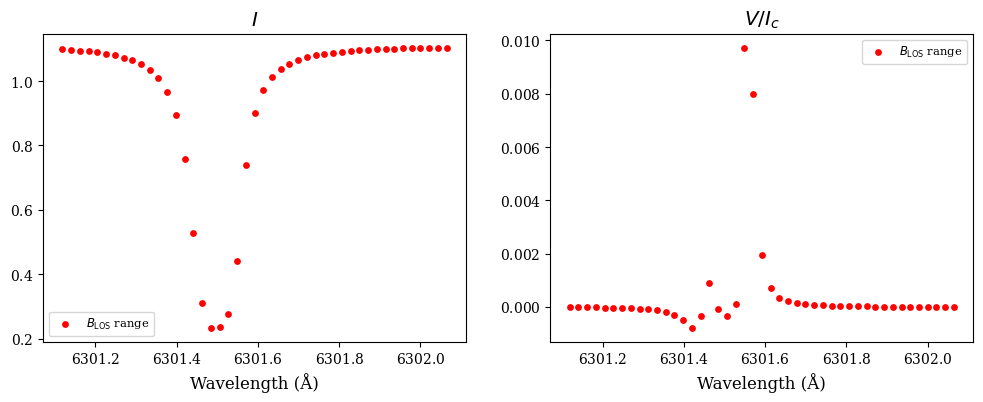

In [7]:
wl_blos_range = [15,60]

# Plot blos wavelength range for profiles.
fig, ax = plt.subplots(1,2, figsize=(12,4))
test_x = 358
test_y = 380
stokes.plot_stokes(ax=ax, x=test_x, y=test_y, wl_index_range = wl_blos_range,scatter=True, color="red", s=15, label=r"$B_\text{LOS}$ range")
plt.show()

In [8]:
blos_wfa = B_LOS_WFA(stokes = stokes.data, 
                                   ll = stokes.wl*u.Angstrom, 
                                   wl_blos_range = wl_blos_range,
                                   llambda0 = llambda0, 
                                   g = g_lande)

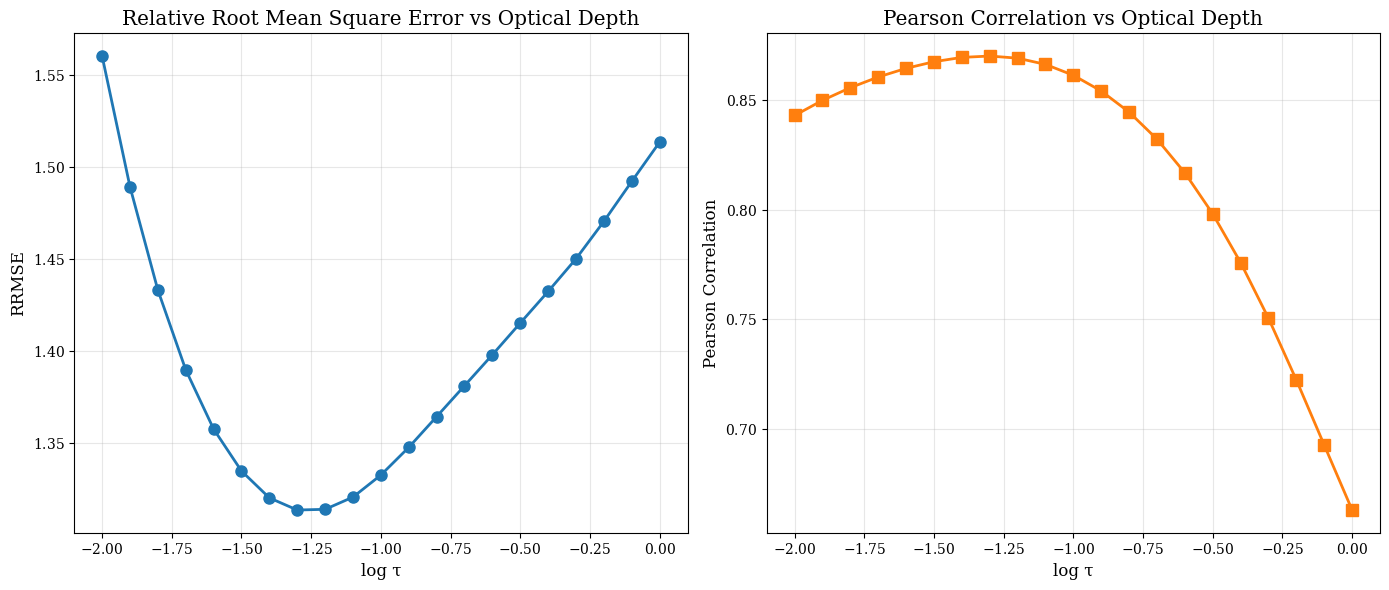

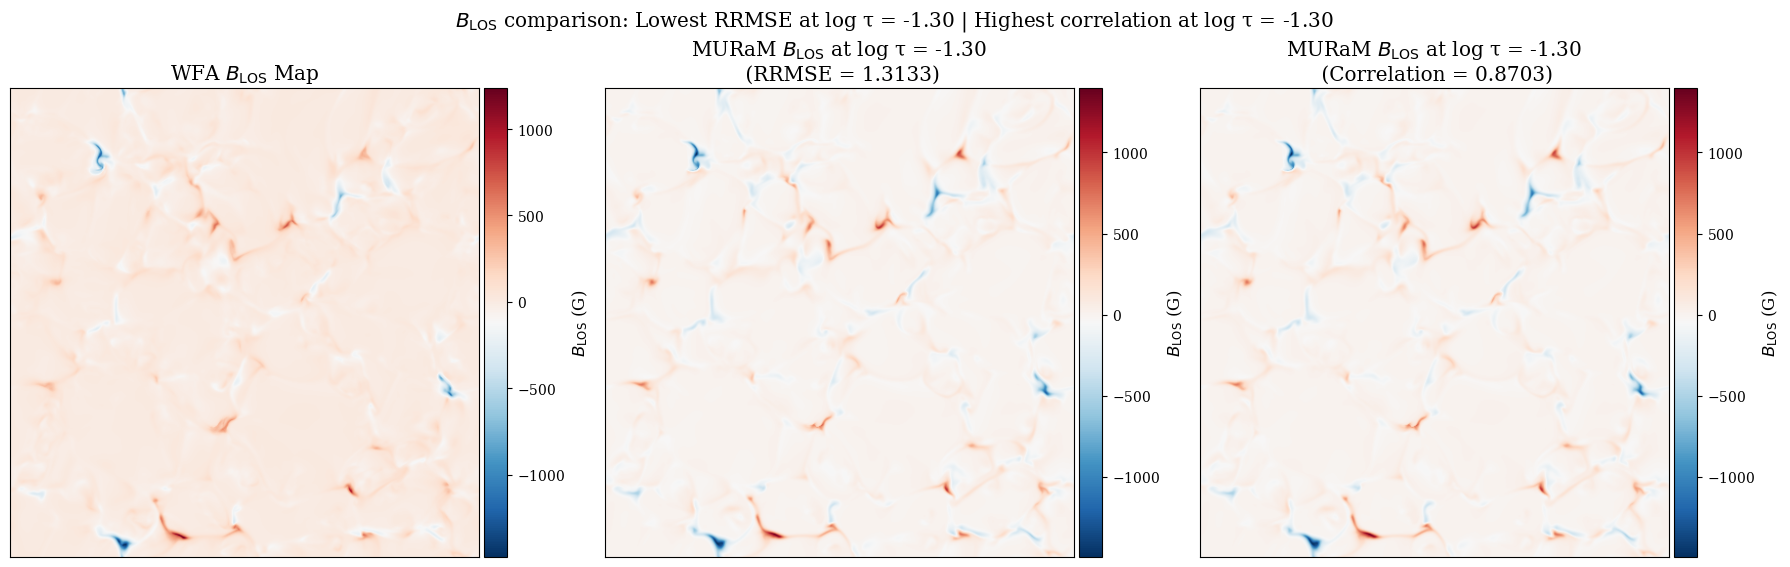

In [9]:
# Run the comparison
compare_approx_with_heights(blos_wfa.value, mhd.od_data["Bz"].value, new_logtau, quantity_name = r"$B_\text{LOS}$")

### 3.2 $v_\text{LOS}$ with zero-refference velocity

For the calculation of the $v_\text{LOS}$ we are going to use the Doppler formula
\begin{equation}
    v_\text{LOS} = \frac{\Delta \lambda}{\lambda_0} c
\end{equation}

Fitted v_LOS: -1.13 km / s


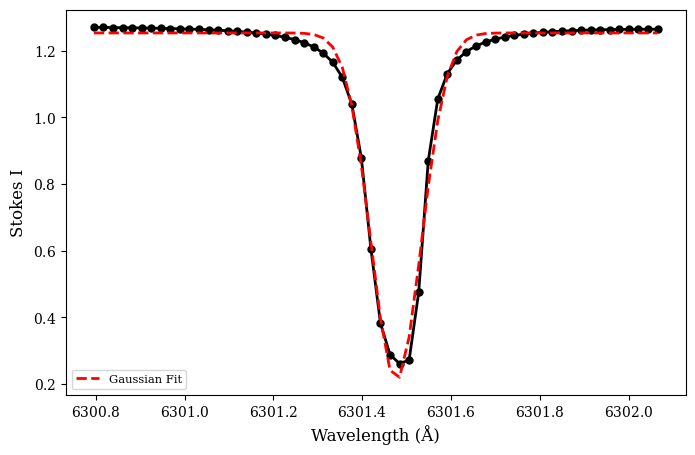

In [ ]:
I_vlos = stokes.data["I"][0,0,:wl_blos_range[1]]
def gaussian_func(x, a, x0, sigma, offset):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset
from scipy.optimize import curve_fit
popt, pcov = curve_fit(gaussian_func, stokes.wl[:wl_blos_range[1]], I_vlos,
                       p0=[1.0, 6301.5, 0.1, 0.0])
a_fit, x0_fit, sigma_fit, offset_fit = popt
I_vlos_fit = gaussian_func(stokes.wl[:wl_blos_range[1]], a_fit, x0_fit, sigma_fit, offset_fit)

v_los = c.to(u.km/u.s) * (x0_fit*u.AA - llambda0.to(u.AA)) / llambda0.to(u.AA)
print(f"Fitted v_LOS: {v_los:.2f}")


fig, ax = plt.subplots(figsize=(8,5))
ax.plot(stokes.wl[:wl_blos_range[1]], I_vlos, color='black', marker='o', markersize=5)
ax.plot(stokes.wl[:wl_blos_range[1]], I_vlos_fit, color='red', linestyle='--', label='Gaussian Fit')
ax.legend()
ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Stokes I")
plt.show()

In [33]:
def vlos_doppler(stokes:dict[str, np.ndarray],
                      ll:np.ndarray,
                      wl_blos_range:list[int],
                      llambda0:float):
    
    v_los_map = np.zeros((stokes.data["I"].shape[0], stokes.data["I"].shape[1])) * u.km/u.s
    def gaussian_func(x, a, x0, sigma, offset):
                return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset
    
    for i in range(stokes.data["I"].shape[0]):
        for j in range(stokes.data["I"].shape[1]):
            I_vlos = stokes.data["I"][i,j,:wl_blos_range[1]]
            
            popt, pcov = curve_fit(gaussian_func, ll[:wl_blos_range[1]], I_vlos,
                                p0=[1.0, 6301.5, 0.1, 0.0])
            a_fit, x0_fit, sigma_fit, offset_fit = popt
            I_vlos_fit = gaussian_func(stokes.wl[:wl_blos_range[1]], a_fit, x0_fit, sigma_fit, offset_fit)

            v_los = c.to(u.km/u.s) * (llambda0.to(u.AA) - x0_fit*u.AA) / llambda0.to(u.AA)
            v_los_map[i,j] = v_los
    
    return v_los_map

In [34]:
vlos_dop = vlos_doppler(stokes = stokes, 
                ll = stokes.wl*u.Angstrom, 
                wl_blos_range = wl_blos_range,
                llambda0 = llambda0)

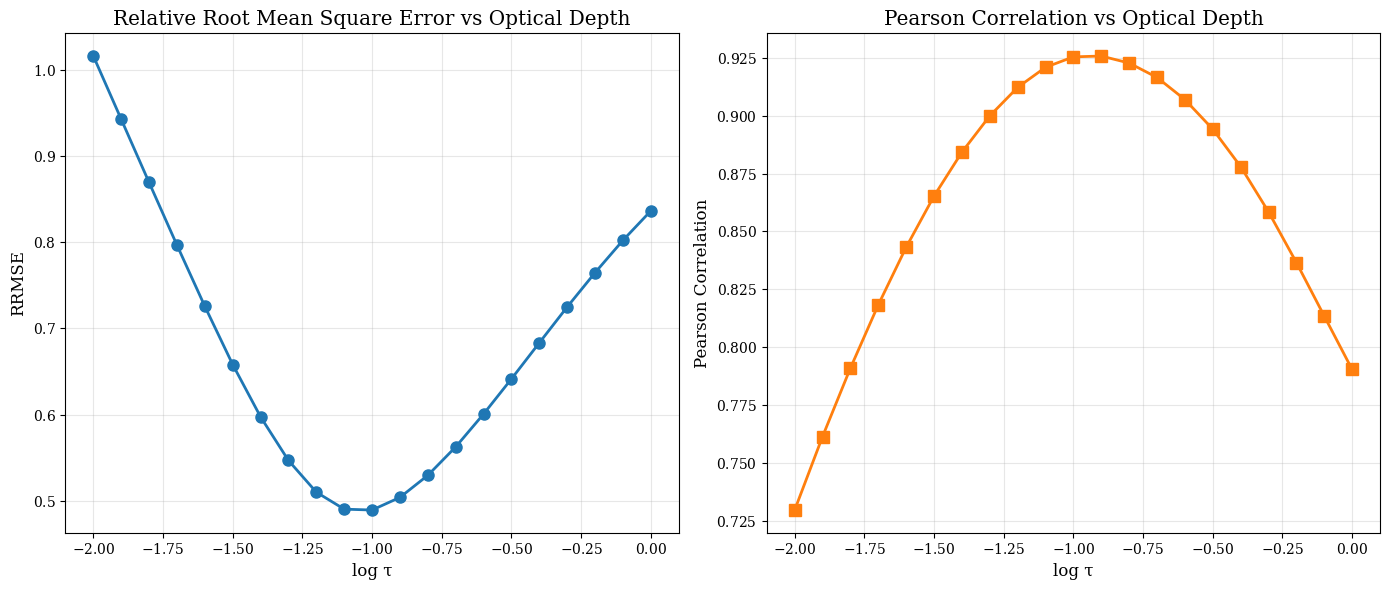

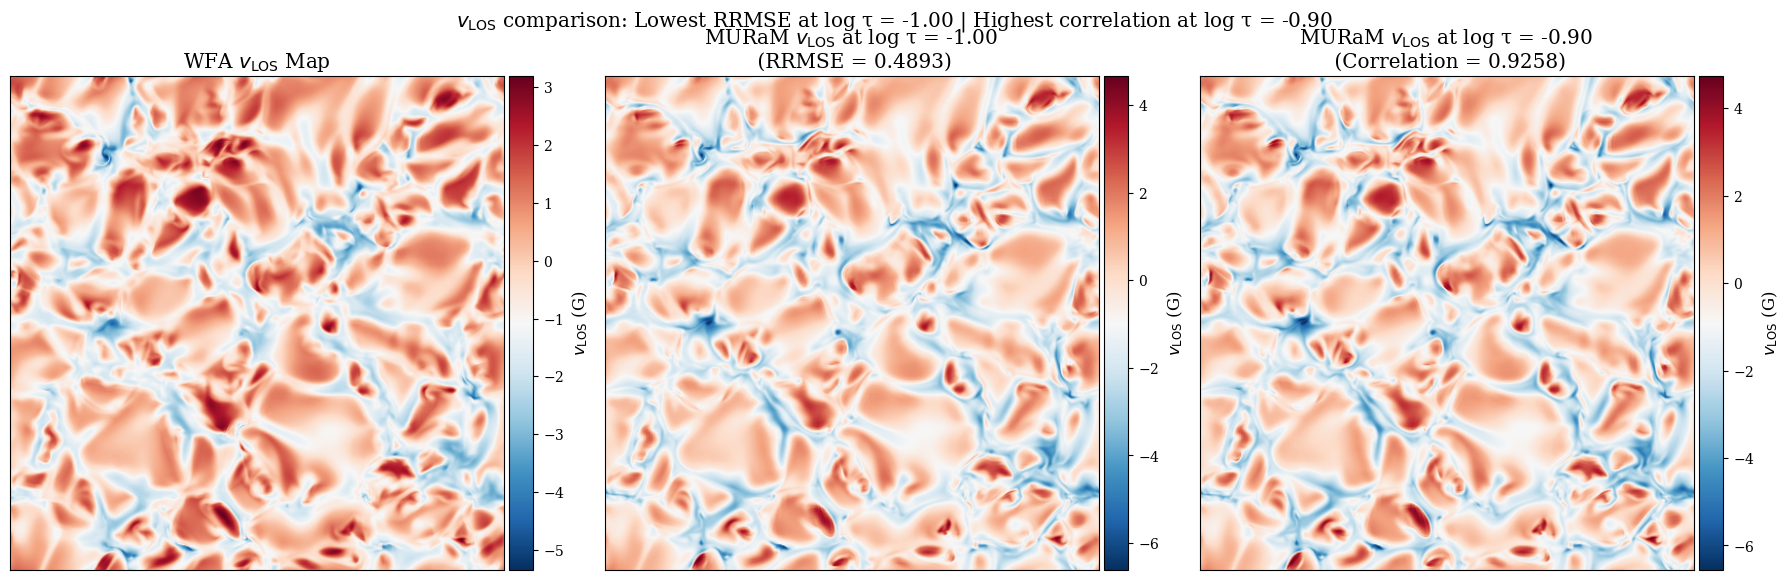

In [35]:
compare_approx_with_heights(vlos_dop.value, mhd.od_data["Vz"].value, new_logtau, quantity_name = r"$v_\text{LOS}$")

## 4. Mean values

In [ ]:
# Cell 1: Define function to compute mean along optical depth using trapezoidal integration
def compute_mean_along_tau(mhd_cube: np.ndarray, logtau_values: np.ndarray) -> np.ndarray:
    """
    Compute the mean value along optical depth using trapezoidal integration.
    
    This mimics the physics loss computation where we integrate B_z or V_z along τ:
    <Q> = ∫ Q(τ) dτ / ∫ dτ
    
    Parameters
    ----------
    mhd_cube : np.ndarray
        3D MHD data cube with shape (nx, ny, nτ)
    logtau_values : np.ndarray
        Array of log10(τ) values, shape (nτ,)
    
    Returns
    -------
    mean_map : np.ndarray
        2D map of tau-averaged values, shape (nx, ny)
    """
    # Convert log(tau) to linear tau
    tau_linear = 10 ** logtau_values  # (nτ,)
    
    # Compute differences for trapezoidal rule
    dtau = np.diff(tau_linear)  # (nτ-1,)
    
    # Average values between consecutive tau points
    # Shape: (nx, ny, nτ-1)
    q_avg = (mhd_cube[:, :, :-1] + mhd_cube[:, :, 1:]) / 2
    
    # Trapezoidal integration: ∫ Q(τ) dτ
    # Broadcast dtau: (1, 1, nτ-1)
    integral_q = np.sum(q_avg * dtau[np.newaxis, np.newaxis, :], axis=2)  # (nx, ny)
    
    # Total tau range: ∫ dτ
    integral_dtau = tau_linear[-1] - tau_linear[0]
    
    # Mean value: <Q> = ∫ Q dτ / ∫ dτ
    mean_map = integral_q / integral_dtau
    
    return mean_map


def compare_approx_with_tau_mean(
    approx_q: np.ndarray,
    muram_q_data: np.ndarray,
    logtau_values: np.ndarray,
    quantity_name: str = "",
    figsize: tuple = (14, 6)
):
    """
    Compare approximated quantity with:
    1. Individual tau heights (per-height RRMSE)
    2. Tau-averaged MURaM values (integrated RRMSE)
    
    Parameters
    ----------
    approx_q : np.ndarray
        2D map of the approximated quantity (nx, ny)
    muram_q_data : np.ndarray
        3D data cube of the MURaM quantity with shape (nx, ny, nτ)
    logtau_values : np.ndarray
        Array of logtau values corresponding to the third axis
    quantity_name : str
        Name of the physical quantity for plot labels
    figsize : tuple
        Figure size for the comparison plots
    """
    nz = muram_q_data.shape[2]
    
    # 1. Per-height RRMSE (existing approach)
    rrmse_per_height = []
    correlation_per_height = []
    
    for k in range(nz):
        muram_q_k = muram_q_data[:, :, k]
        rmse = np.sqrt(np.mean((approx_q - muram_q_k)**2))
        rrmse = rmse / (np.mean(np.abs(muram_q_k)) + 1e-10)
        rrmse_per_height.append(rrmse)
        
        corr, _ = pearsonr(approx_q.flatten(), muram_q_k.flatten())
        correlation_per_height.append(corr)
    
    # 2. Tau-averaged RRMSE (new approach - physics-informed)
    muram_q_mean = compute_mean_along_tau(muram_q_data, logtau_values)
    
    rmse_mean = np.sqrt(np.mean((approx_q - muram_q_mean)**2))
    rrmse_mean = rmse_mean / (np.mean(np.abs(muram_q_mean)) + 1e-10)
    corr_mean, _ = pearsonr(approx_q.flatten(), muram_q_mean.flatten())
    
    # Find best per-height metrics
    min_rrmse_idx = np.argmin(rrmse_per_height)
    max_corr_idx = np.argmax(correlation_per_height)
    min_logtau_rrmse = logtau_values[min_rrmse_idx]
    min_rrmse = rrmse_per_height[min_rrmse_idx]
    max_logtau_corr = logtau_values[max_corr_idx]
    max_corr = correlation_per_height[max_corr_idx]
    
    # Print comparison
    print("=" * 70)
    print(f"RRMSE Comparison for {quantity_name}")
    print("=" * 70)
    print(f"\n📊 Per-Height Analysis (existing approach):")
    print(f"   Best RRMSE:       {min_rrmse:.6f} at log τ = {min_logtau_rrmse:.2f}")
    print(f"   Best Correlation: {max_corr:.6f} at log τ = {max_logtau_corr:.2f}")
    print(f"\n🔬 Tau-Averaged Analysis (physics-informed approach):")
    print(f"   RRMSE:            {rrmse_mean:.6f}")
    print(f"   Correlation:      {corr_mean:.6f}")
    print(f"\n📈 Improvement Metrics:")
    rrmse_improvement = ((min_rrmse - rrmse_mean) / min_rrmse) * 100
    corr_improvement = ((corr_mean - max_corr) / max_corr) * 100
    print(f"   RRMSE change:     {rrmse_improvement:+.2f}% {'(better)' if rrmse_improvement > 0 else '(worse)'}")
    print(f"   Correlation change: {corr_improvement:+.2f}% {'(better)' if corr_improvement > 0 else '(worse)'}")
    print("=" * 70)
    
    # Plot 1: Per-height metrics vs tau-averaged
    fig, ax = plt.subplots(1, 2, figsize=figsize)
    
    # RRMSE comparison
    ax[0].plot(logtau_values, rrmse_per_height, marker='o', linewidth=2, 
               markersize=8, color='C0', label='Per-height RRMSE')
    ax[0].axhline(y=rrmse_mean, color='C3', linestyle='--', linewidth=2.5, 
                  label=f'Tau-averaged RRMSE = {rrmse_mean:.4f}')
    ax[0].axhline(y=min_rrmse, color='C0', linestyle=':', linewidth=1.5, alpha=0.5,
                  label=f'Best per-height = {min_rrmse:.4f}')
    ax[0].set_xlabel('log τ')
    ax[0].set_ylabel('RRMSE')
    ax[0].set_title('RRMSE: Per-Height vs Tau-Averaged')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # Correlation comparison
    ax[1].plot(logtau_values, correlation_per_height, marker='s', linewidth=2, 
               markersize=8, color='C1', label='Per-height Correlation')
    ax[1].axhline(y=corr_mean, color='C3', linestyle='--', linewidth=2.5,
                  label=f'Tau-averaged Corr = {corr_mean:.4f}')
    ax[1].axhline(y=max_corr, color='C1', linestyle=':', linewidth=1.5, alpha=0.5,
                  label=f'Best per-height = {max_corr:.4f}')
    ax[1].set_xlabel('log τ')
    ax[1].set_ylabel('Pearson Correlation')
    ax[1].set_title('Correlation: Per-Height vs Tau-Averaged')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Spatial maps comparison
    fig, ax = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'{quantity_name} Comparison: Approximation vs Ground Truth', 
                 fontsize='xx-large', y=0.995)
    
    # Determine common colorbar limits
    vmin = min(approx_q.min(), muram_q_data.min(), muram_q_mean.min())
    vmax = max(approx_q.max(), muram_q_data.max(), muram_q_mean.max())
    
    # Row 1: Approximation and tau-averaged comparison
    # WFA/Doppler approximation
    im0 = ax[0, 0].imshow(approx_q, origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax[0, 0].set_title(f'Approximation\n({quantity_name})')
    ax[0, 0].set_xticks([])
    ax[0, 0].set_yticks([])
    divider0 = make_axes_locatable(ax[0, 0])
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im0, cax=cax0)
    
    # Tau-averaged MURaM
    im1 = ax[0, 1].imshow(muram_q_mean, origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax[0, 1].set_title(f'MURaM Tau-Averaged\nRRMSE = {rrmse_mean:.4f} | Corr = {corr_mean:.4f}')
    ax[0, 1].set_xticks([])
    ax[0, 1].set_yticks([])
    divider1 = make_axes_locatable(ax[0, 1])
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax=cax1)
    
    # Difference map: Approximation - Tau-averaged
    diff_mean = approx_q - muram_q_mean
    im2 = ax[0, 2].imshow(diff_mean, origin='lower', cmap='seismic', 
                          vmin=-np.abs(diff_mean).max(), vmax=np.abs(diff_mean).max())
    ax[0, 2].set_title(f'Difference\n(Approx - Tau-Avg)')
    ax[0, 2].set_xticks([])
    ax[0, 2].set_yticks([])
    divider2 = make_axes_locatable(ax[0, 2])
    cax2 = divider2.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax=cax2)
    
    # Row 2: Best per-height comparisons
    # Best RRMSE height
    im3 = ax[1, 0].imshow(muram_q_data[:, :, min_rrmse_idx], origin='lower', 
                          cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax[1, 0].set_title(f'MURaM at log τ = {min_logtau_rrmse:.2f}\n(Best per-height RRMSE = {min_rrmse:.4f})')
    ax[1, 0].set_xticks([])
    ax[1, 0].set_yticks([])
    divider3 = make_axes_locatable(ax[1, 0])
    cax3 = divider3.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im3, cax=cax3)
    
    # Best correlation height
    im4 = ax[1, 1].imshow(muram_q_data[:, :, max_corr_idx], origin='lower', 
                          cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax[1, 1].set_title(f'MURaM at log τ = {max_logtau_corr:.2f}\n(Best per-height Corr = {max_corr:.4f})')
    ax[1, 1].set_xticks([])
    ax[1, 1].set_yticks([])
    divider4 = make_axes_locatable(ax[1, 1])
    cax4 = divider4.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im4, cax=cax4)
    
    # Histogram comparison
    ax[1, 2].hist(approx_q.flatten(), bins=50, alpha=0.6, label='Approximation', color='C0')
    ax[1, 2].hist(muram_q_mean.flatten(), bins=50, alpha=0.6, label='Tau-Averaged', color='C3')
    ax[1, 2].hist(muram_q_data[:, :, min_rrmse_idx].flatten(), bins=50, alpha=0.4, 
                  label=f'Best Height (τ={min_logtau_rrmse:.2f})', color='C1')
    ax[1, 2].set_xlabel(f'{quantity_name} Value')
    ax[1, 2].set_ylabel('Frequency')
    ax[1, 2].set_title('Value Distribution Comparison')
    ax[1, 2].legend()
    ax[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Return metrics for further analysis
    return {
        'per_height': {
            'rrmse_values': rrmse_per_height,
            'correlation_values': correlation_per_height,
            'best_rrmse': min_rrmse,
            'best_rrmse_logtau': min_logtau_rrmse,
            'best_corr': max_corr,
            'best_corr_logtau': max_logtau_corr,
        },
        'tau_averaged': {
            'rrmse': rrmse_mean,
            'correlation': corr_mean,
            'muram_mean_map': muram_q_mean,
        },
        'improvements': {
            'rrmse_change_percent': rrmse_improvement,
            'corr_change_percent': corr_improvement,
        }
    }

🔬 Analyzing B_LOS (Magnetic Field)
----------------------------------------------------------------------
RRMSE Comparison for $B_\mathrm{LOS}$

📊 Per-Height Analysis (existing approach):
   Best RRMSE:       1.313263 at log τ = -1.30
   Best Correlation: 0.870277 at log τ = -1.30

🔬 Tau-Averaged Analysis (physics-informed approach):
   RRMSE:            1.357662
   Correlation:      0.792901

📈 Improvement Metrics:
   RRMSE change:     -3.38% (worse)
   Correlation change: -8.89% (worse)


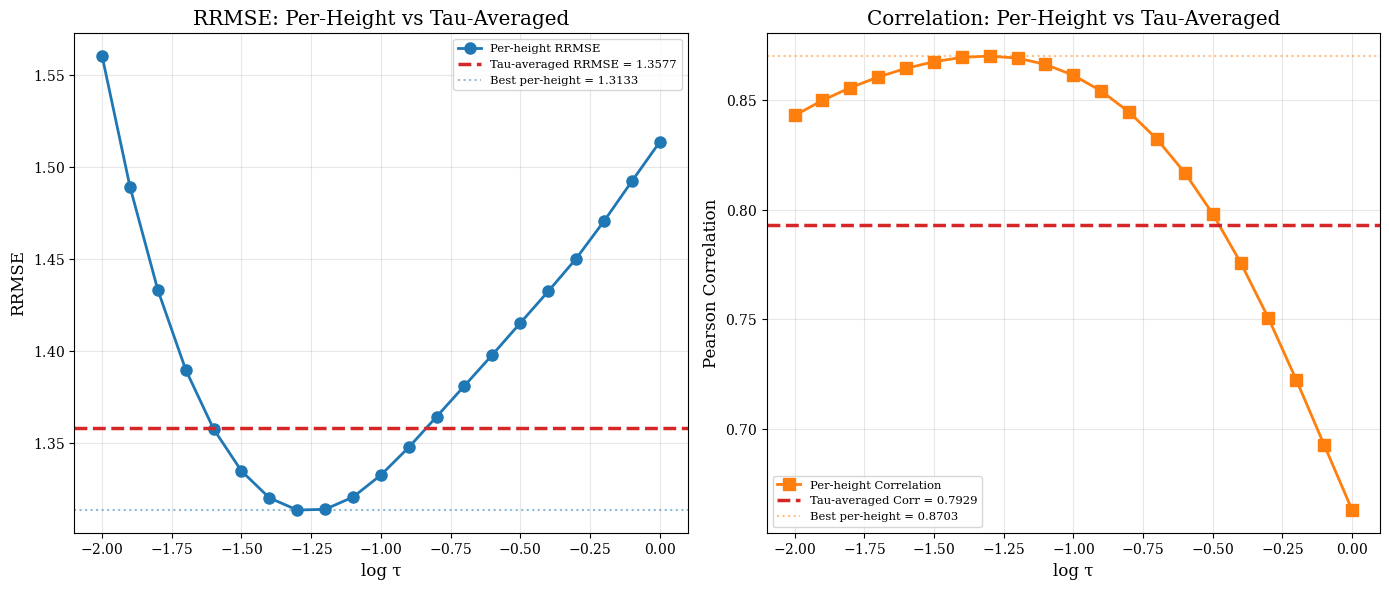

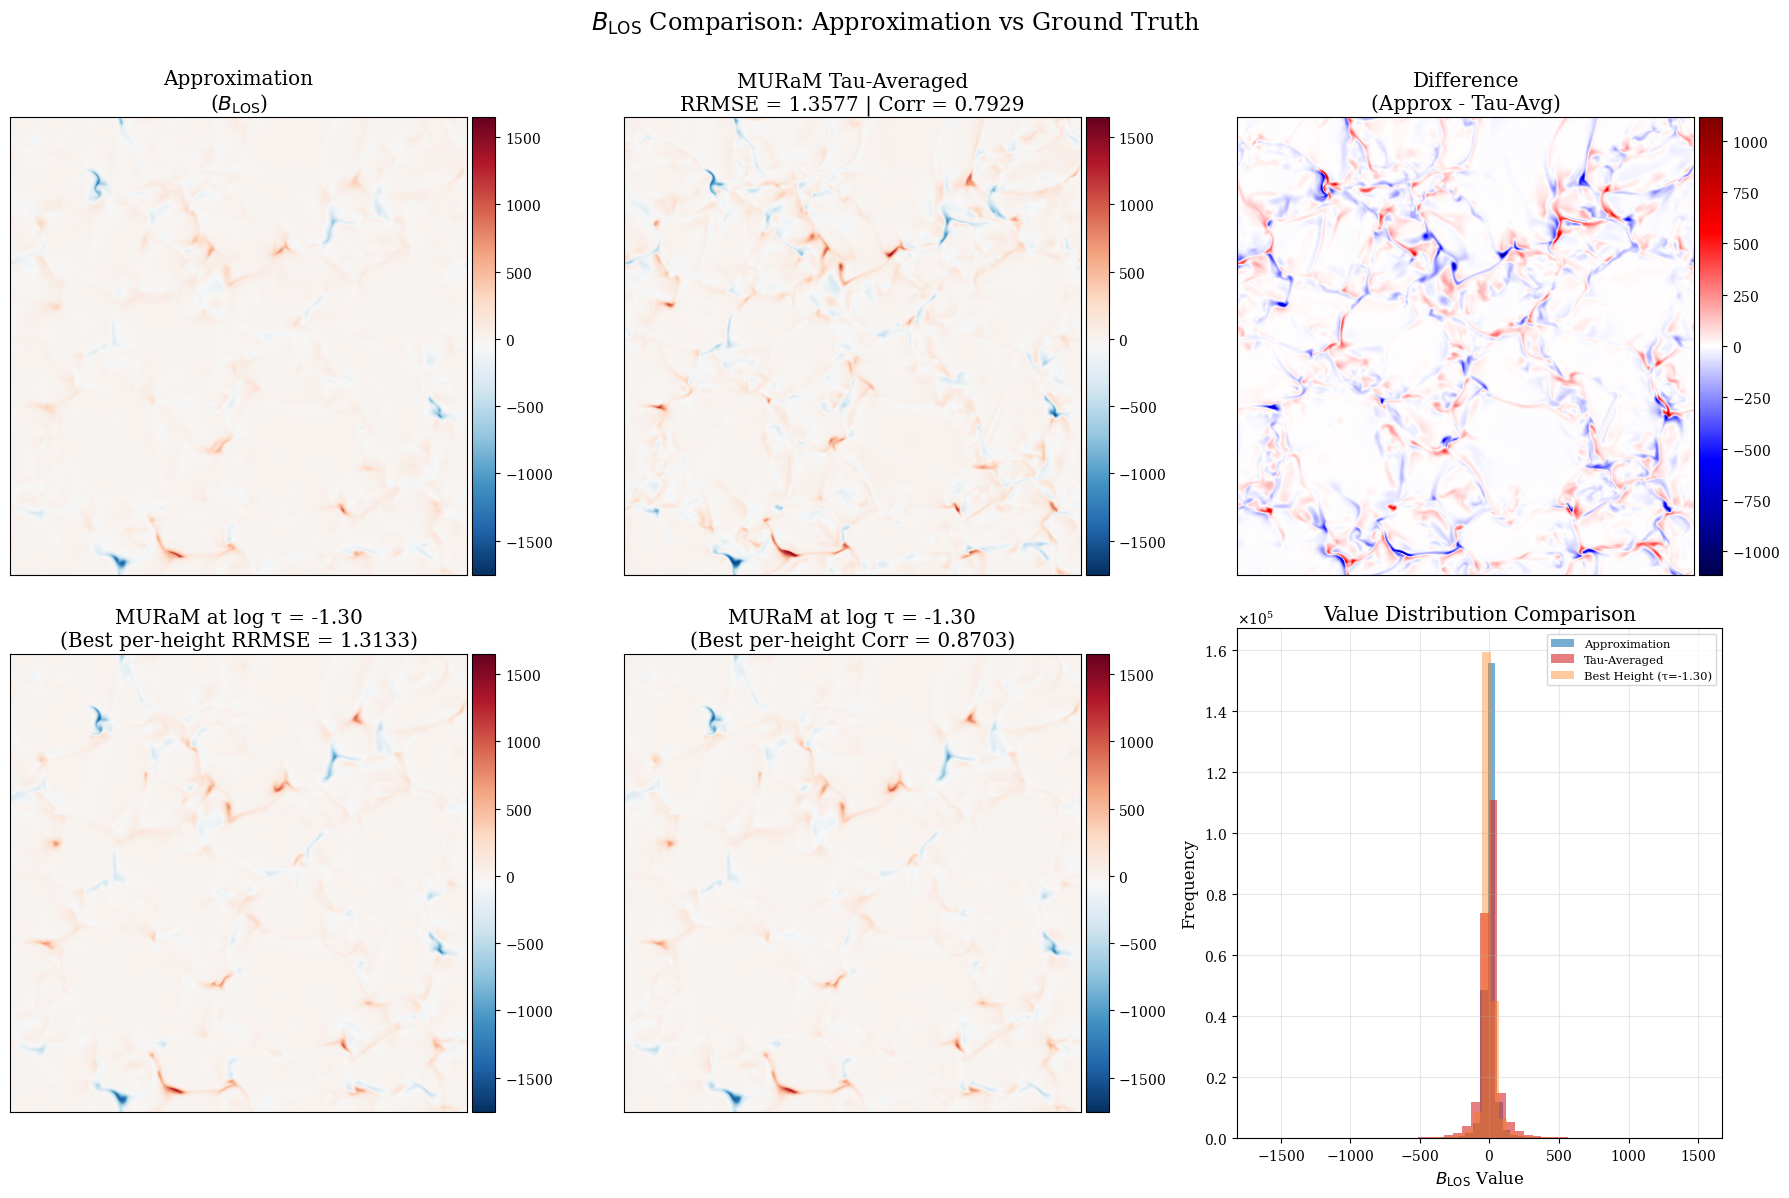



🔬 Analyzing V_LOS (Line-of-Sight Velocity)
----------------------------------------------------------------------
RRMSE Comparison for $v_\mathrm{LOS}$

📊 Per-Height Analysis (existing approach):
   Best RRMSE:       6.462749 at log τ = 0.00
   Best Correlation: -0.057127 at log τ = 0.00

🔬 Tau-Averaged Analysis (physics-informed approach):
   RRMSE:            8.035831
   Correlation:      -0.078301

📈 Improvement Metrics:
   RRMSE change:     -24.34% (worse)
   Correlation change: +37.07% (better)


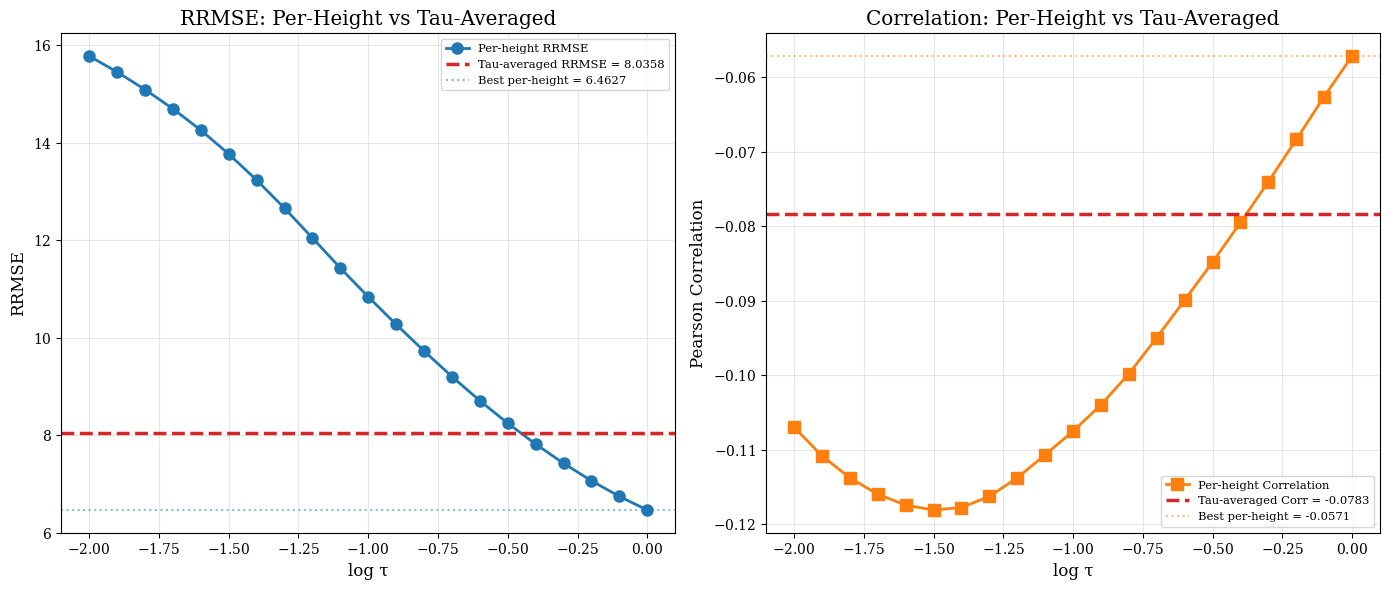

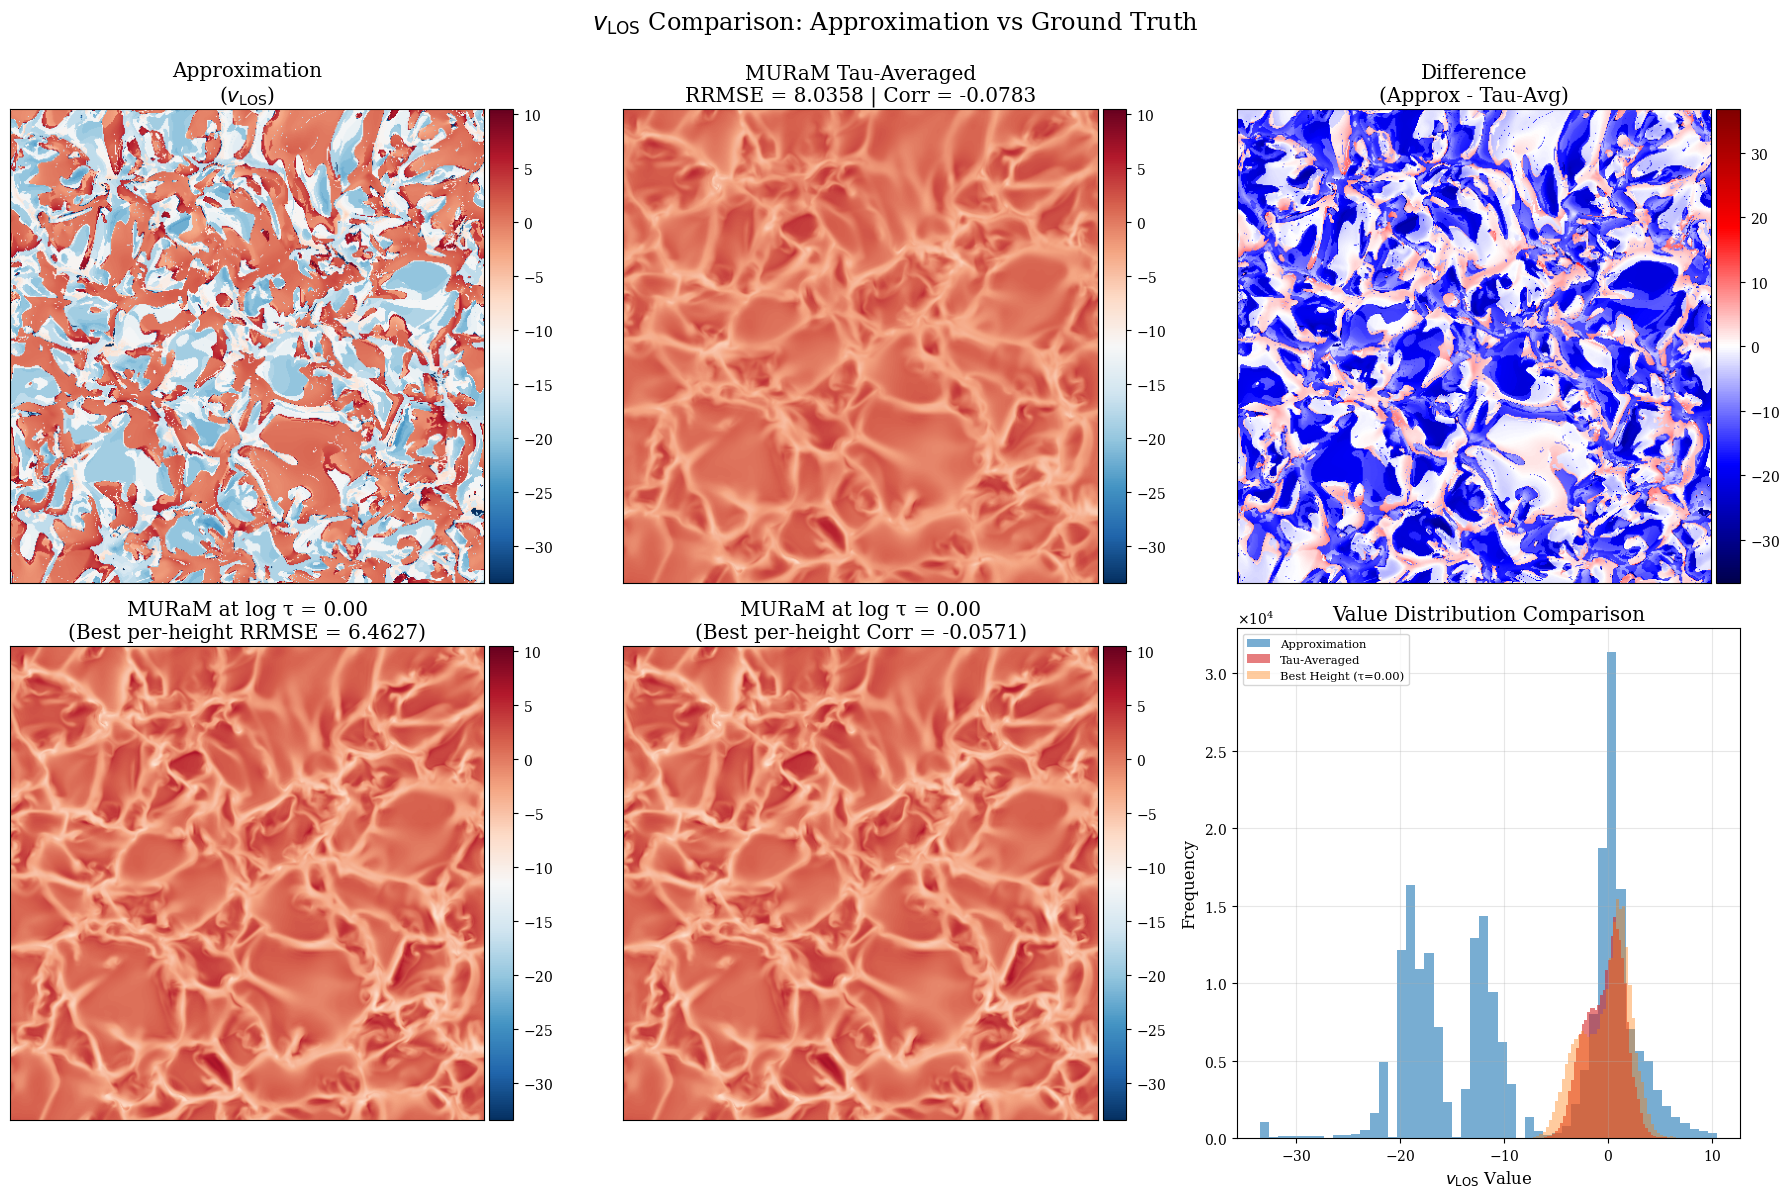


SUMMARY: Per-Height vs Tau-Averaged Approach

Quantity        Metric               Per-Height      Tau-Averaged    Δ%        
----------------------------------------------------------------------
B_LOS           RRMSE                1.313263        1.357662            -3.38%
B_LOS           Correlation          0.870277        0.792901            -8.89%
V_LOS           RRMSE                6.462749        8.035831           -24.34%
V_LOS           Correlation          -0.057127       -0.078301          +37.07%

📖 Interpretation Guide:
----------------------------------------------------------------------
Positive Δ% → Tau-averaged approach performs BETTER
Negative Δ% → Per-height approach performs BETTER

The tau-averaged approach:
  ✓ Matches the physics loss computation used in training
  ✓ Represents line-of-sight integration (physical reality)
  ✓ Avoids arbitrary single-height selection
  ✗ May blur sharp vertical gradients


In [ ]:
# Cell 2: Apply the new comparison function to B_LOS and V_LOS

print("🔬 Analyzing B_LOS (Magnetic Field)")
print("-" * 70)
blos_metrics = compare_approx_with_tau_mean(
    approx_q=blos_wfa.value,
    muram_q_data=mhd.od_data["Bz"].value,
    logtau_values=new_logtau,
    quantity_name=r"$B_\mathrm{LOS}$"
)

print("\n" + "="*70 + "\n")

print("🔬 Analyzing V_LOS (Line-of-Sight Velocity)")
print("-" * 70)
vlos_metrics = compare_approx_with_tau_mean(
    approx_q=vlos_dop.value,
    muram_q_data=mhd.od_data["Vz"].value,
    logtau_values=new_logtau,
    quantity_name=r"$v_\mathrm{LOS}$"
)

# Summary comparison table
print("\n" + "="*70)
print("SUMMARY: Per-Height vs Tau-Averaged Approach")
print("="*70)
print(f"\n{'Quantity':<15} {'Metric':<20} {'Per-Height':<15} {'Tau-Averaged':<15} {'Δ%':<10}")
print("-" * 70)

# B_LOS comparison
print(f"{'B_LOS':<15} {'RRMSE':<20} {blos_metrics['per_height']['best_rrmse']:<15.6f} "
      f"{blos_metrics['tau_averaged']['rrmse']:<15.6f} "
      f"{blos_metrics['improvements']['rrmse_change_percent']:>+9.2f}%")
print(f"{'B_LOS':<15} {'Correlation':<20} {blos_metrics['per_height']['best_corr']:<15.6f} "
      f"{blos_metrics['tau_averaged']['correlation']:<15.6f} "
      f"{blos_metrics['improvements']['corr_change_percent']:>+9.2f}%")

# V_LOS comparison
print(f"{'V_LOS':<15} {'RRMSE':<20} {vlos_metrics['per_height']['best_rrmse']:<15.6f} "
      f"{vlos_metrics['tau_averaged']['rrmse']:<15.6f} "
      f"{vlos_metrics['improvements']['rrmse_change_percent']:>+9.2f}%")
print(f"{'V_LOS':<15} {'Correlation':<20} {vlos_metrics['per_height']['best_corr']:<15.6f} "
      f"{vlos_metrics['tau_averaged']['correlation']:<15.6f} "
      f"{vlos_metrics['improvements']['corr_change_percent']:>+9.2f}%")

print("="*70)

# Interpretation guide
print("\n📖 Interpretation Guide:")
print("-" * 70)
print("Positive Δ% → Tau-averaged approach performs BETTER")
print("Negative Δ% → Per-height approach performs BETTER")
print("\nThe tau-averaged approach:")
print("  ✓ Matches the physics loss computation used in training")
print("  ✓ Represents line-of-sight integration (physical reality)")
print("  ✓ Avoids arbitrary single-height selection")
print("  ✗ May blur sharp vertical gradients")
print("="*70)